In [1]:
import sys
sys.path.append('../')

import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
from eval_utils import load_data

from collections import Counter
import os
import numpy as np
from tqdm import tqdm

from pymatgen.core.structure import Structure
from pymatgen.core.composition import Composition
from pymatgen.core.lattice import Lattice

from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)
from pymatgen.io.cif import CifWriter

from pymatgen.analysis.structure_analyzer import SpacegroupAnalyzer

from compute_metrics import get_crystal_array_list, all_results_retreival, Crystal

from eval_utils import (
    smact_validity, structure_validity, CompScaler, get_fp_pdist,
    load_config, load_data, get_crystals_list, compute_cov)

#replaced args.label with label
def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

def list_cif_writer(data_dir, predicted_crystal_list, gt_structure_list, symprec = None):
    for i in tqdm(range(len(predicted_crystal_list))): 
        crystal = Crystal(predicted_crystal_list[i])    
        structure = crystal.structure
        full_formula = structure.composition.formula
        file_path = data_dir + '/pred_{}_{}.cif'.format(full_formula, i)
        if symprec is not None: 
            CifWriter(structure, symprec = symprec).write_file(file_path)
        CifWriter(structure).write_file(file_path)
    
    for i in tqdm(range(len(gt_structure_list))):
        structure = Crystal(gt_structure_list[i]).structure
        full_formula = structure.composition.formula
        file_path = data_dir + '/gt_{}_{}.cif'.format(full_formula, i)
        if symprec is not None: 
            CifWriter(structure, symprec = symprec).write_file(file_path)
        CifWriter(structure).write_file(file_path)

def MAPE(y_true, y_pred): 
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100

def cosine_similarity(patternx, patterny):
    return np.dot(patternx, patterny) / (np.linalg.norm(patternx) * np.linalg.norm(patterny))
from tqdm import tqdm
def mape_calculator(gt_crystals, best_crystals): 
    #calculate the MAPE for the lengths and angles
    per_crystal_mape_lengths = []   
    per_crystal_mape_angles = []
    for i in tqdm(range(len(best_crystals))): 
        gt_lengths = gt_crystals[i]['lengths']
        gt_angles = gt_crystals[i]['angles']
        pred_lengths = best_crystals[i]['lengths']
        pred_angles = best_crystals[i]['angles']
        per_crystal_mape_lengths.append(MAPE(gt_lengths, pred_lengths))
        per_crystal_mape_angles.append(MAPE(gt_angles, pred_angles))

    return per_crystal_mape_lengths, per_crystal_mape_angles

def hist_plot(data, title, xlabel, ylabel):
    plt.hist(data, bins = 100)
    plt.title(title)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

def rmsd_and_mards_plotter(lowest_rmsd, per_crystal_mape_lengths, per_crystal_mape_angles):
    #plot a histogram of the rmsds 
    hist_plot(lowest_rmsd, 'RMSD for Crystal Structures', 'RMSD', 'Count')
    
    #plot a histogram of the MAPEs for the lengths
    hist_plot(per_crystal_mape_lengths, 'MAPE for Crystal Structure Lengths', 'MAPE', 'Count')

    #plot a histogram of the MAPEs for the angles
    hist_plot(per_crystal_mape_angles, 'MAPE for Crystal Structure Angles', 'MAPE', 'Count')

def get_best_crystals(total_rmsd, all_gt, all_results, plot = True, use_lp_metrics = ""):
    
    nan_rows = np.argwhere(np.isnan(total_rmsd))
    rows_with_only_nans = np.where(np.all(np.isnan(total_rmsd), axis=1))[0]
    
    list_of_all_lattice_mapes = []
    #for every batch 
    for i in range(len(all_results)): 
        #fetch the gt and pred crystals for that batch
        gt_crystals = all_gt[i]
        pred_crystals = all_results[i]

        #calculate the MAPE for the lengths and angles
        per_crystal_mape_lengths, per_crystal_mape_angles = mape_calculator(gt_crystals, pred_crystals)
        list_of_all_lattice_mapes.append(per_crystal_mape_lengths)
        
    #apply np array
    list_of_all_lattice_mapes = np.array(list_of_all_lattice_mapes)
    #reshape by transposing
    list_of_all_lattice_mapes = list_of_all_lattice_mapes.T

    #if a value is nan in total rmsd, set it to a very large number in the list of all lattice mapes
    list_of_all_lattice_mapes[nan_rows[:, 0], nan_rows[:, 1]] = 1000000

    if use_lp_metrics != "":
        #take the nan min to get the lowest metric and lowest metric indices
        lowest_metric = np.nanmin(list_of_all_lattice_mapes, axis=1)
        lowest_metric_indices = np.nanargmin(np.nan_to_num(list_of_all_lattice_mapes, nan=1), axis=1)

    else:
        lowest_metric = np.nanmin(total_rmsd, axis=1)
        lowest_metric_indices = np.nanargmin(np.nan_to_num(total_rmsd, nan=1), axis=1)
        
    #use these values to find the best crystal from all_results
    best_crystals = []
    for i in range(len(all_results[0])): 
        indice = lowest_metric_indices[i]
        best_crystals.append(all_results[indice][i])

    gt_crystals = all_gt[0]

    #remove the values with only nans (no matches)
    best_crystals = [i for j, i in enumerate(best_crystals) if j not in rows_with_only_nans]
    gt_crystals = [i for j, i in enumerate(gt_crystals) if j not in rows_with_only_nans]

    #use the lowest metric indices to fetch the corresponding rmsd values 
    lowest_rmsd = []
    for i in range(len(lowest_metric_indices)): 
        lowest_rmsd.append(total_rmsd[i][lowest_metric_indices[i]])
    lowest_rmsd = np.array(lowest_rmsd)

    #use the lowest metric indices to fetch the corresponding mapes
    lowest_mapes = []
    for i in range(len(lowest_metric_indices)): 
        lowest_mapes.append(list_of_all_lattice_mapes[i][lowest_metric_indices[i]])
    lowest_mapes = np.array(lowest_mapes)

    return lowest_metric, best_crystals, gt_crystals, lowest_rmsd, lowest_mapes

def symmetryops(structure, symprec):
    sga = SpacegroupAnalyzer(structure, symprec=symprec)
    space_group_symbol = sga.get_space_group_symbol()
    space_group_number = sga.get_space_group_number()  # Get the space group number
    symmetrized_structure = sga.get_refined_structure()
    return space_group_symbol, space_group_number, symmetrized_structure

def symmetry_performance(snapped_crystal_list, pred_crystal_list, gt_crystal_list, tolmax = 2):
    snapped_spacegroups = []
    pred_spacegroups = []
    snapped_tolerance = []
    pred_tolerance = []

    for i in tqdm(range(len(snapped_crystal_list))): 
        snapped_found = False
        pred_found = False

        snapped_structure = Crystal(snapped_crystal_list[i]).structure
        if pred_crystal_list is not None:
            pred_structure = Crystal(pred_crystal_list[i]).structure
        gt_structure = Crystal(gt_crystal_list[i]).structure
        
        gt_spacegroup, gt_sg_num, gt_symmetrized_structure = symmetryops(gt_structure, 0.01)

        for symprec in np.arange(0.01, tolmax, 0.1):
            try: 
                if not snapped_found: 
                    snapped_spacegroup, snapped_sg_num, snapped_symmetrized_structure = symmetryops(snapped_structure, symprec)
                if not pred_found and pred_crystal_list is not None:
                    pred_spacegroup, pred_sg_num, pred_symmetrized_structure = symmetryops(pred_structure, symprec)
            except: 
                continue

            if snapped_sg_num == gt_sg_num and not snapped_found:
                snapped_tolerance.append(symprec)
                snapped_spacegroups.append(snapped_sg_num)
                snapped_found = True

            if pred_crystal_list is not None: 
                if pred_sg_num == gt_sg_num and not pred_found:
                    pred_tolerance.append(symprec)
                    pred_spacegroups.append(pred_sg_num)
                    pred_found = True

            if snapped_found and pred_found:
                break            

            if symprec == np.max(np.arange(0.01, tolmax, 0.1)):
                if not snapped_found: 
                    snapped_spacegroups.append(snapped_sg_num)
                    snapped_tolerance.append(-1)

                if not pred_found and pred_crystal_list is not None:
                    pred_spacegroups.append(pred_sg_num)
                    pred_tolerance.append(-1)
                    
    snapped_spacegroups = np.array(snapped_spacegroups)
    snapped_tolerance = np.array(snapped_tolerance)

    if pred_crystal_list is not None:
        pred_spacegroups = np.array(pred_spacegroups)
        pred_tolerance = np.array(pred_tolerance)

    return snapped_spacegroups, pred_spacegroups, snapped_tolerance, pred_tolerance

In [2]:
# config_dict = {
#     "model_path": '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/augmented_vae_nopf',
#     "label": 'PDF_unsolved_compounds',
#     "num_batches": 64,
#     "data_dir": '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/Result_Data/Fig3', 
#     "results_label": 'fs_total_rmsd_ae_pf_5batches_64_evals',
# }

config_dict = {
    "model_path": '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/vae_nopf',
    "label": '5_batches_64_evals',
    "num_batches": 64,
}

# config_dict = {
#     "model_path": '/home/gridsan/tmackey/hydra/singlerun/2024-01-29/augmented_vae_nopf',
#     "label": 'RRUFF_data_test_only_using_amcsd',
#     "num_batches": 64,
#     "data_dir": '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/Result_Data/Fig3', 
#     "results_label": 'RRUFF_data_test_only_using_amcsd',
# }

In [3]:
model_path = config_dict['model_path']
label = config_dict['label']
recon_file_path = get_file_paths(model_path, 'recon',label=label)
num_batches = config_dict['num_batches']

all_results, all_gt = all_results_retreival(recon_file_path, False, num_batches, label = label)

100%|██████████| 64/64 [00:06<00:00,  9.78it/s]


In [4]:
data_dir = os.path.join(config_dict['model_path'], config_dict['label'])

def load_and_merge(data_dir, num_workers, type_of_data):
    for i in tqdm(range(num_workers)):
        filename = os.path.join(data_dir, f'worker_{i}_{type_of_data}.npy')
        if i == 0: 
            total_data = np.load(filename)
        else:
            data = np.load(filename, allow_pickle=True)
            total_data = np.concatenate((total_data, data), axis=1)

    return total_data

In [35]:
total_rmsd = load_and_merge(data_dir, 100, 'fs_total_rmsd')
pred_tolerance = load_and_merge(data_dir, 100, 'fs_pred_tolerance')
pred_spacegroups = load_and_merge(data_dir, 100, 'fs_pred_spacegroups')
gt_spacegroups = load_and_merge(data_dir, 100, 'fs_gt_spacegroups')

100%|██████████| 100/100 [00:00<00:00, 1023.87it/s]


In [8]:
#take the lowest rmsd value down the rows 
lowest_rmsd  = np.nanmin(total_rmsd, axis=0)

/tmp/ipykernel_3031245/1994071298.py:2: RuntimeWarning: All-NaN slice encountered
  lowest_rmsd  = np.nanmin(total_rmsd, axis=0)


In [11]:
np.nanmean(lowest_rmsd)

0.03975875825169739

In [36]:
pred_tolerance_sum = np.sum(pred_tolerance, axis=0)

In [37]:
pred_tolerance_sum

array([-64.  , -64.  , -64.  , ..., -55.05,   0.64, -30.73])

In [38]:
np.mean(pred_tolerance_sum != -64)

0.8276150627615063

In [39]:
#find the columns in total rmsd that are all nans
nan_only_columns = np.where(np.all(np.isnan(total_rmsd), axis=0))[0]

In [40]:
pred_tolerance_only_matched = np.array([entry for i, entry in enumerate(pred_tolerance_sum) if i not in nan_only_columns])

In [41]:
np.mean(pred_tolerance_only_matched != -64)

0.9035087719298246

In [53]:
#change -1 values in pred_tolerance to nan
pred_tolerance_nans = pred_tolerance.copy()
pred_tolerance_nans[pred_tolerance_nans == -1] = np.nan
#if the value is nan in total rmsd, set the corresponding value in pred tolerance to nan
pred_tolerance_nans[np.isnan(total_rmsd)] = np.nan

In [54]:
#remove rows with all nans using the variable from earlier
pred_tolerance_nans = np.delete(pred_tolerance_nans, nan_only_columns, axis=1)

In [55]:
#find the minimum tolerance for each crystal 
min_tolerance = np.nanmin(pred_tolerance_nans, axis=0)

/tmp/ipykernel_4139778/3354746816.py:2: RuntimeWarning: All-NaN slice encountered
  min_tolerance = np.nanmin(pred_tolerance_nans, axis=0)


In [56]:
np.nanmean(min_tolerance)

0.14312883435582824

In [16]:
total_mape_lengths = []
total_mape_angles = []
for i in range(num_batches):
    per_crystal_mape_lengths, per_crystal_mape_angles = mape_calculator(all_gt[0], all_results[0])
    total_mape_lengths.append(per_crystal_mape_lengths)
    total_mape_angles.append(per_crystal_mape_angles)

100%|██████████| 1195/1195 [00:00<00:00, 25142.81it/s]


In [21]:
print("mape lengths is, ", np.mean(total_mape_lengths))
print("mape angles is, ", np.mean(total_mape_angles))

mape lengths is,  8.098553004879193
mape angles is,  6.410563759920752


In [61]:
result_label = config_dict['label']
crystal_index = 3
total_rmsd_crystal = total_rmsd[:, crystal_index]
pred_tolerance_crystal = pred_tolerance[:, crystal_index]
pred_crystals = [i[crystal_index] for i in all_results]
folder_name = f"/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/02-10-2024_RRUFF_snap/"
subfolder_name = os.path.join(folder_name, result_label)
if not os.path.exists(subfolder_name):
    os.makedirs(subfolder_name)

for batch_num in range(num_batches):
    batch_subfolder_name = os.path.join(subfolder_name, f'batch_{batch_num}')
    if not os.path.exists(batch_subfolder_name): 
        os.makedirs(batch_subfolder_name)

In [60]:
zipped_crystal_and_total_rmsd = zip(pred_crystals, total_rmsd_crystal)
tolerance_crystal_dict = sorted({tolerance : c_rmsd for tolerance, c_rmsd in zip(pred_tolerance_crystal, zipped_crystal_and_total_rmsd)}.items())

for tolerance, crystal_rmsd in tolerance_crystal_dict: 
    crystal, rmsd = crystal_rmsd
    batch_num = 0
    if rmsd != 10:
        batch_folder = os.path.join(subfolder_name, f'batch_{batch_num}')
        
        crystal = Crystal(crystal)
        structure = crystal.structure
        full_formula = structure.composition.formula
        file_path = batch_folder + '/pred_{}_{}.cif'.format(full_formula, crystal_index)
        CifWriter(structure).write_file(file_path)

In [4]:
result_label = "PDF"
for i in range(config_dict['num_batches']):
    folder_name = f"/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/02-10-2024_RRUFF_snap/test_{i}_structures_{result_label}"
    #make the directory 
    os.makedirs(folder_name, exist_ok=True)
    predicted_structures = all_results[i]
    gt_structures = all_gt[i]
    list_cif_writer(folder_name, predicted_structures, gt_structures, symprec = 0.001)

  0%|          | 0/1195 [00:00<?, ?it/s]

 30%|██▉       | 353/1195 [00:10<00:25, 32.83it/s]


KeyboardInterrupt: 

In [53]:
total_rmsd = load_and_merge(config_dict["data_dir"], label = config_dict["results_label"])

In [39]:
snapped_spacegroups, pred_spacegroups, snapped_tolerance, pred_tolerance = symmetry_performance(snapped_crystal_list[0], pred_crystal_list[0], gt_crystal_list[0], tolmax = 2.1)

100%|██████████| 741/741 [04:39<00:00,  2.65it/s]


In [48]:
#save the snapped_spacegroups, pred_spacegroups, snapped_tolerance, pred_tolerance to /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/Result_Data/Symmetrization_Statistics
label = "five_batch_vae_nopf"
sym_result_dir = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/Result_Data/Symmetrization_Statistics"
np.save(sym_result_dir+ f'/{label}_snapped_spacegroups.npy', snapped_spacegroups)
np.save(sym_result_dir + f'/{label}_pred_spacegroups.npy', pred_spacegroups)
np.save(sym_result_dir + f'/{label}_snapped_tolerance.npy', snapped_tolerance)
np.save(sym_result_dir + f'/{label}_pred_tolerance.npy', pred_tolerance)

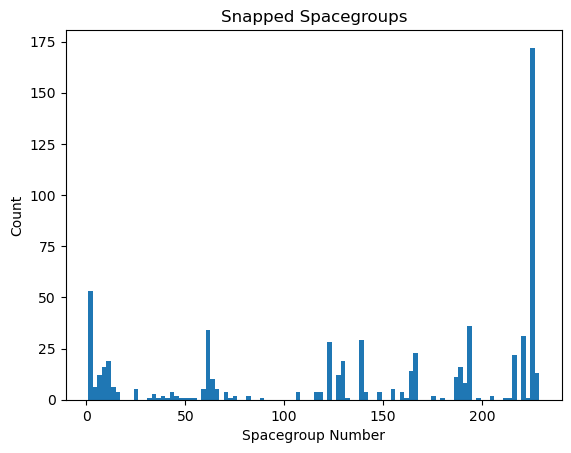

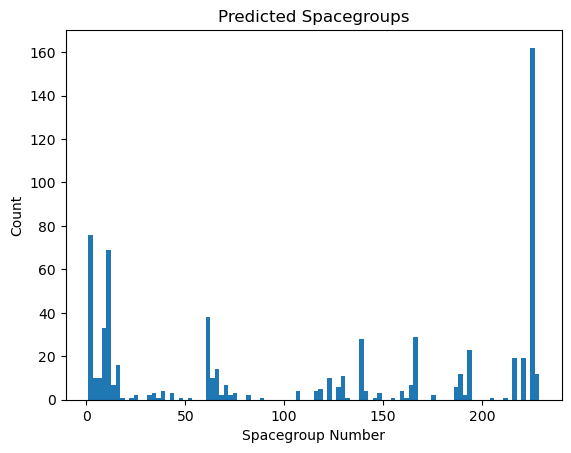

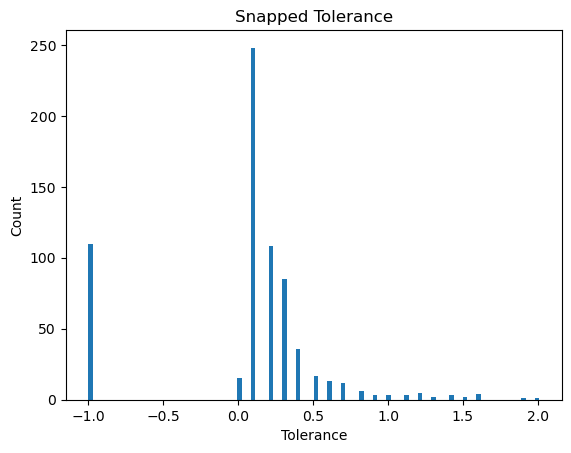

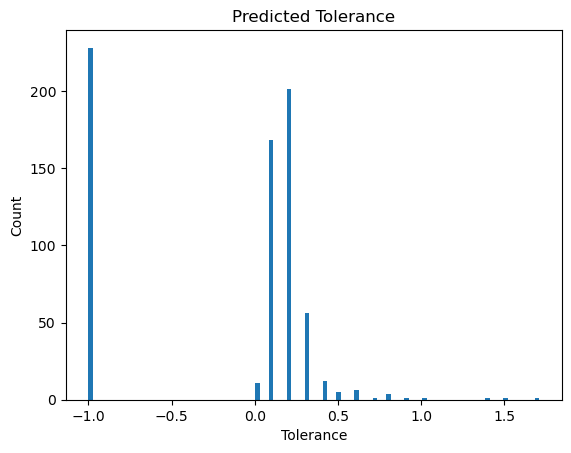

In [49]:
#make a histogram of the snapped_spacegroups
hist_plot(snapped_spacegroups, 'Snapped Spacegroups', 'Spacegroup Number', 'Count')
hist_plot(pred_spacegroups, 'Predicted Spacegroups', 'Spacegroup Number', 'Count')
hist_plot(snapped_tolerance, 'Snapped Tolerance', 'Tolerance', 'Count')
hist_plot(pred_tolerance, 'Predicted Tolerance', 'Tolerance', 'Count')

In [21]:
pred_spacegroup_all_batches = []
pred_tolerance_all_batches = []

for i in range(1, 5):
    _, pred_spacegroups, _, pred_tolerance = symmetry_performance(all_results[0][:10], None, all_gt[0][:10], tolmax = 2.1)
    pred_spacegroup_all_batches.append(pred_spacegroups)
    pred_tolerance_all_batches.append(pred_tolerance)

100%|██████████| 10/10 [00:03<00:00,  3.11it/s]


In [29]:
pred_tolerance_all_batches_s = np.stack(pred_tolerance_all_batches)

In [30]:
#take the cumulative sum of pred_tolerance_all_batches_s down the columns
cum_sum = np.cumsum(pred_tolerance_all_batches_s, axis = 0)

In [31]:
np.mean(cum_sum[-1, :] > -63)

/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/fromnumeric.py:3464: RuntimeWarning: Mean of empty slice.
  return _methods._mean(a, axis=axis, dtype=dtype,
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/_methods.py:192: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret.dtype.type(ret / rcount)


nan

Step 1, part 1: get the RMSDs for all of the correctly matched structures. 

In [96]:
metric, best_crystals, gt_crystals, lowest_rmsd, lowest_mapes = get_best_crystals(total_rmsd, all_gt, all_results, plot = False, use_lp_metrics = "length")

100%|██████████| 69/69 [00:04<00:00, 16.18it/s]


Now, test set 2 focuses on compounds with the worst lattice parameter predictions. Obviously, some of them are terrible, and we can filter them out of the result even if it means that we take a hit on performance. Let's choose lattice parameters that are towards the worse end of the distribution, but not total outliers. 

In [40]:
def crystal_symmetrization(best_crystals, gt_crystals): 
    symmetrized_crystals = []
    space_group_numbers = []
    ground_truth_spacegroup_nums = []   
    for i in tqdm(range(len(best_crystals))): 
        try:
            gtcrys = Crystal(gt_crystals[i])
            gtstructure = gtcrys.structure
            ___, gtspace_group_number, gtsymmetrized_structure = symmetryops(gtstructure, 0.01)

            list_of_symprecs = [0.01, 0.05, 0.1, 0.5]
            crys = Crystal(best_crystals[i])
            structure = crys.structure
            for symprec in list_of_symprecs:
                ___, space_group_number, symmetrized_structure = symmetryops(structure, symprec)
                if space_group_number == gtspace_group_number:
                    break
            
            symmetrized_crystals.append(symmetrized_structure)
            space_group_numbers.append(space_group_number)
            ground_truth_spacegroup_nums.append(gtspace_group_number)
            
        except Exception as e:
            continue

    return symmetrized_crystals, space_group_numbers, ground_truth_spacegroup_nums

In [41]:
symmetrized_crystals, space_group_numbers, ground_truth_spacegroup_nums = crystal_symmetrization(best_crystals, gt_crystals)

100%|██████████| 820/820 [01:05<00:00, 12.51it/s]


In [42]:
#find all entries in spacegroup numbers that match the corresponding ground truth spacegroup numbers
matching_spacegroup_indices = []
for i in range(len(space_group_numbers)): 
    if space_group_numbers[i] == ground_truth_spacegroup_nums[i]: 
        matching_spacegroup_indices.append(i)

In [43]:
len(matching_spacegroup_indices)

627

In [19]:
def list_cif_writer_from_pymg(data_dir, predicted_crystal_list, gt_structure_list, symprec = None):
    for i in tqdm(range(len(predicted_crystal_list))): 
        structure = predicted_crystal_list[i]
        full_formula = structure.composition.reduced_formula
        formula = full_formula.replace(" ", "")
        file_path = data_dir + '/pred_{}_{}.cif'.format(formula, i)
        if symprec is not None: 
            CifWriter(structure, symprec = symprec).write_file(file_path)
        CifWriter(structure).write_file(file_path)
    
    for i in tqdm(range(len(gt_structure_list))):
        structure = gt_structure_list[i]
        full_formula = structure.composition.reduced_formula
        formula = full_formula.replace(" ", "")
        file_path = data_dir + '/gt_{}_{}.cif'.format(formula, i)
        if symprec is not None: 
            CifWriter(structure, symprec = symprec).write_file(file_path)
        CifWriter(structure).write_file(file_path)

In [23]:
!mkdir /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/sym_compounds_for_DFT
data_dir = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/sym_compounds_for_DFT'
list_cif_writer_from_pymg(data_dir, filtered_symmetrized_crystals, [], symprec=0.01)

100%|██████████| 639/639 [01:04<00:00,  9.89it/s]


TypeError: object of type 'NoneType' has no len()

In [97]:
import os

# Directory where your CIF files are stored
cif_directory = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/RRUFF_crystals_best_lattice_params_for_DFT'
# New directory to save the modified CIF files (to keep original files unchanged)
modified_cif_directory = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/RRUFF_crystals_best_lattice_params_for_DFT_modified'

# Make sure the modified CIF directory exists
os.makedirs(modified_cif_directory, exist_ok=True)

# Database code to add
database_code_lines = [
    "# generated using pymatgen\n",
    "# generated using pymatgen\n",
    "data_43574-ICSD\n",
    "_database_code_ICSD 43574\n",
    "_audit_creation_date 2000-07-15\n",
    "_audit_update_record 2015-08-01\n",
]

# Loop through all files in the directory
for filename in os.listdir(cif_directory):
    if filename.endswith(".cif"):  # Check if the file is a CIF file
        filepath = os.path.join(cif_directory, filename)
        modified_filepath = os.path.join(modified_cif_directory, filename)
        
        with open(filepath, 'r') as file:
            lines = file.readlines()
        
        #remove the first line
        lines = lines[2:]
        
        # Insert the database code at the beginning or a specific position
        lines = database_code_lines + lines
        
        # Write the modified lines to a new file in the modified directory
        with open(modified_filepath, 'w') as file:
            file.writelines(lines)

print("Modification of CIF files completed.")


Modification of CIF files completed.


Finally, let's get cosine similarity between the diffraction patterns generated from the predicted and true crystal structures so we can get a kind of "before and after".

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import torch
import os

In [19]:
def caglioti_fwhm(theta, U, V, W):
    """
    Calculate the FWHM using the Caglioti formula.
    theta: float, the angle in degrees
    U, V, W: Caglioti parameters
    """
    rad_theta = np.radians(theta / 2)  # Convert theta to radians
    return (U * np.tan(rad_theta)**2 + V * np.tan(rad_theta) + W)**0.5

def pseudo_voigt(x, center, amplitude, U, V, W, eta, noise_sd=0.0):
    """
    Pseudo-Voigt function using Caglioti FWHM.
    x: array-like, the independent variable
    center: float, the center of the peak
    amplitude: float, the height of the peak
    U, V, W: Caglioti parameters
    eta: float, the fraction of the Lorentzian component (0 <= eta <= 1)
    """
    fwhm = caglioti_fwhm(center, U, V, W)
    sigma = fwhm / (2 * np.sqrt(2 * np.log(2)))  # Convert FWHM to sigma for Gaussian
    # Generate random noise from a normal distribution
    noise = np.random.normal(0, noise_sd)

    noisy_percentage = (100 + noise_sd) / 100 
    #print("noisy_percentage is ", noisy_percentage)

    #multiply the amplitude by the noisy percentage 
    amplitude = amplitude * noisy_percentage
    
    lorentzian = amplitude * (fwhm**2 / ((x - center)**2 + fwhm**2))
    gaussian = amplitude * np.exp(-(x - center)**2 / (2 * sigma**2))
    return eta * lorentzian + (1 - eta) * gaussian

def superimposed_pseudo_voigt(x, xy_merge, U, V, W, eta, noise_sd=0.0):
    """
    Superimpose multiple pseudo-Voigt functions using Caglioti FWHM.
    x: array-like, the independent variable
    xy_merge: nx2 array, first column is peak locations, second column is intensities
    U, V, W: Caglioti parameters
    eta: float, the fraction of the Lorentzian component (0 <= eta <= 1)
    """
    total = np.zeros_like(x)
    for row in xy_merge:
        center, amplitude = row
        total += pseudo_voigt(x, center, amplitude, U, V, W, eta, noise_sd)
    total = total / max(total)
    return total

# Function to simulate XRD for each row
def simulate_pv_xrd_for_row(xy_merge, U, V, W, noise=0.0):

    x = np.arange(5, 90, 0.010)
    eta = 0  # Fraction of Lorentzian component (common for all peaks)

    sim_xrd = superimposed_pseudo_voigt(x, xy_merge, U, V, W, eta, noise_sd=noise)

    return sim_xrd

def get_sim_xrd_from_crystal_list(cryslist, index):
    """
    Get the simulated XRD pattern for a single crystal in the list.
    cryslist: list of Crystal objects
    index: int, the index of the crystal in the list
    """
    crys = Crystal(cryslist[index])
    pattern =  xrd_calculator.get_pattern(crys.structure)
    xy_merge = np.column_stack((pattern.x, pattern.y))

    U, V, W = 0.1, 0.1, 0.1 
    sim_xrd = simulate_pv_xrd_for_row(xy_merge, U, V, W, noise=0.0)
    return sim_xrd

def get_cosine_similarities_from_crystal_lists(best_crystals, gt_crystals):
    """
    Get the cosine similarities between the simulated XRD patterns for two lists of crystals.
    cryslist1: list of Crystal objects
    cryslist2: list of Crystal objects
    """
    consine_similarity_values = []
    for i in tqdm(range(len(best_crystals))): 
        pred_pv_xrd = get_sim_xrd_from_crystal_list(best_crystals, i)
        gt_pv_xrd = get_sim_xrd_from_crystal_list(gt_crystals, i)
        consine_similarity_values.append(cosine_similarity(pred_pv_xrd, gt_pv_xrd))

    return consine_similarity_values

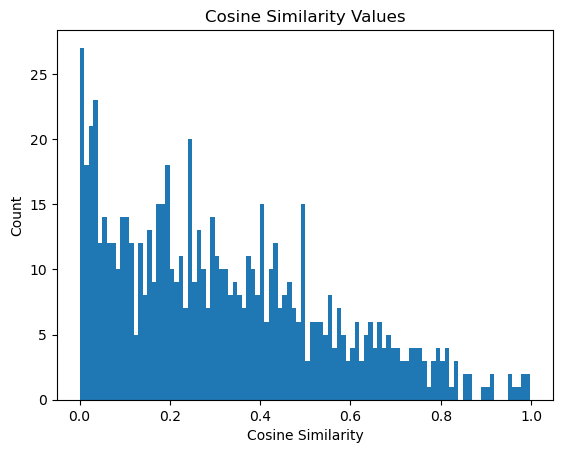

In [ ]:
#make a histogram of the cosine similarity values
plt.hist(consine_similarity_values, bins=100)
plt.title('Cosine Similarity Values')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.show()

In [ ]:
#what's the mean 
mean_cosine_similarity = np.mean(consine_similarity_values)
mean_cosine_similarity

0.31802336594128966

Now, let's repeat this process with each of the test sets that we generated. 

In [ ]:
def cosine_similarity_results(predicted_crystals, gt_crystals):
    best_crystals = predicted_crystals
    for i in tqdm(range(len(best_crystals))): 
        pred_pv_xrd = get_sim_xrd_from_crystal_list(best_crystals, i)
        gt_pv_xrd = get_sim_xrd_from_crystal_list(gt_crystals, i)
        consine_similarity_values.append(cosine_similarity(pred_pv_xrd, gt_pv_xrd))

    return consine_similarity_values

In [ ]:
#apply the cosine similarity results function to the worst lattice parameters and angles data
worst_lps = cosine_similarity_results(worst_crystals_lengths_and_angles, gt_crystals)

 16%|█▋        | 56/343 [00:26<02:18,  2.07it/s]


KeyboardInterrupt: 

In [ ]:
#apply the cosine similarity results function to the worst rmsd data
worst_rmsd = cosine_similarity_results(worst_crystals_rmsd, gt_crystals)

Step 4: Get performance metrics for the snapped compounds 

First, let's get all the before/after data as well as the ground truth data. The ground truth and before data is the same as when we wrote it to the cif files, so we can just read it back in.

In [66]:
import numpy as np 
from pymatgen.analysis.diffraction.xrd import XRDCalculator
xrd_calculator = XRDCalculator(wavelength='CuKa', symprec=0.1)


In [67]:
from tqdm import tqdm 

In [73]:
import os
from pymatgen.io.cif import CifParser

def get_structures_from_cif(directory, pred_or_gt = "pred"):
    # Filter files that start with 'pred' and end with '.cif'
    cif_files = [f for f in os.listdir(directory) if f.startswith(pred_or_gt) and f.endswith(".cif")]

    # Initialize a dictionary to store the structures
    structures = {}

    for cif_file in tqdm(cif_files):
        try: 
            file_path = os.path.join(directory, cif_file)
            parser = CifParser(file_path)
            structure = parser.get_structures()[0]  # Assuming you want the first structure in the CIF file
            #add the entry where the filenme is the key and the structure is the value
            structures[cif_file] = structure

        except: 
            print("Error with file: ", file_path)
            continue

    return structures
#now, we want to associate the snapped structures with the corresponding predicted and gt structures. we can do this with the number in the filename right before .cif
#because the key is the filename, we can extract the number and then loop through the pred and gt keys to find the corresponding structures

def get_tuple_list(snapped_structures, pred_structures, gt_structures):
    list_of_snapped_pred_gt_tuples = []

    for key in tqdm(snapped_structures.keys()):
        #extract the number from the key
        num = key.split("_")[-1].split(".")[0]
        #find the corresponding pred and gt structures by looping through all the entries and looking for one with the same sufficx
        for pred_key in pred_structures.keys():
            pred_num = pred_key.split("_")[-1].split(".")[0]
            if pred_num == num:
                pred_structure = pred_structures[pred_key]
                break

        for gt_key in gt_structures.keys():
            gt_num = gt_key.split("_")[-1].split(".")[0]
            if gt_num == num:
                gt_structure = gt_structures[gt_key]
                break

        list_of_snapped_pred_gt_tuples.append((snapped_structures[key], pred_structure, gt_structure))

    return list_of_snapped_pred_gt_tuples

Now we have all the data to start making figures. Let's start with what will give Hamed's figure / will be the most compelling argument: the rmsd values before and after snapping. To do this, we will need to make CDVAE crystal structure objects from the snapped data. 

In [74]:
def pymg_to_crystal_list(list_of_pymatgen_structures):
    crystal_list = []
    for structure in list_of_pymatgen_structures: 
        crys_array_dict = {
            'frac_coords': np.array(structure.frac_coords),
            'atom_types': np.array(structure.atomic_numbers),
            'lengths': np.array(structure.lattice.abc),
            'angles': np.array(structure.lattice.angles),
        }
        crystal_list.append(crys_array_dict)
    return crystal_list

At this point, we can bring in the handy evaluate function we made for the evaluation notebook to take care of the rmsd values.

In [75]:
from pymatgen.analysis.structure_matcher import StructureMatcher
from eval_utils import (
    smact_validity, structure_validity)

def get_file_paths(root_path, task, label='', suffix='pt'):
    if label == '':
        out_name = f'eval_{task}.{suffix}'
    else:
        out_name = f'eval_{task}_{label}.{suffix}'
    out_name = os.path.join(root_path, out_name)
    return out_name

def get_crystals_list(
        frac_coords, atom_types, lengths, angles, num_atoms):
    """
    args:
        frac_coords: (num_atoms, 3)
        atom_types: (num_atoms)
        lengths: (num_crystals)
        angles: (num_crystals)
        num_atoms: (num_crystals)
    """
    assert frac_coords.size(0) == atom_types.size(0) == num_atoms.sum()
    assert lengths.size(0) == angles.size(0) == num_atoms.size(0)

    start_idx = 0
    crystal_array_list = []
    for batch_idx, num_atom in enumerate(num_atoms.tolist()):
        cur_frac_coords = frac_coords.narrow(0, start_idx, num_atom)
        cur_atom_types = atom_types.narrow(0, start_idx, num_atom)
        cur_lengths = lengths[batch_idx]
        cur_angles = angles[batch_idx]

        crystal_array_list.append({
            'frac_coords': cur_frac_coords.detach().cpu().numpy(),
            'atom_types': cur_atom_types.detach().cpu().numpy(),
            'lengths': cur_lengths.detach().cpu().numpy(),
            'angles': cur_angles.detach().cpu().numpy(),
        })
        start_idx = start_idx + num_atom
    return crystal_array_list

class Crystal(object):
    def __init__(self, crys_array_dict):
        self.frac_coords = crys_array_dict['frac_coords']
        self.atom_types = crys_array_dict['atom_types']
        self.lengths = crys_array_dict['lengths']
        self.angles = crys_array_dict['angles']
        self.dict = crys_array_dict

        self.get_structure()
        self.get_composition()
        self.get_validity()
        #self.get_fingerprints()
    def get_structure(self):
        if min(self.lengths.tolist()) < 0:
            self.constructed = False
            self.invalid_reason = 'non_positive_lattice'
        else:
            try:
                self.structure = Structure(
                    lattice=Lattice.from_parameters(
                        *(self.lengths.tolist() + self.angles.tolist())),
                    species=self.atom_types, coords=self.frac_coords, coords_are_cartesian=False)
                self.constructed = True
            except Exception:
                self.constructed = False
                self.invalid_reason = 'construction_raises_exception'
            if self.structure.volume < 0.1:
                self.constructed = False
                self.invalid_reason = 'unrealistically_small_lattice'
    def get_composition(self):
        elem_counter = Counter(self.atom_types)
        composition = [(elem, elem_counter[elem])
                       for elem in sorted(elem_counter.keys())]
        elems, counts = list(zip(*composition))
        counts = np.array(counts)
        counts = counts / np.gcd.reduce(counts)
        self.elems = elems
        self.comps = tuple(counts.astype('int').tolist())
    def get_validity(self):
        self.comp_valid = smact_validity(self.elems, self.comps)
        if self.constructed:
            self.struct_valid = structure_validity(self.structure)
        else:
            self.struct_valid = False
        self.valid = self.comp_valid and self.struct_valid
    def get_fingerprints(self):
        elem_counter = Counter(self.atom_types)
        comp = Composition(elem_counter)
        self.comp_fp = CompFP.featurize(comp)
        try:
            site_fps = [CrystalNNFP.featurize(
                self.structure, i) for i in range(len(self.structure))]
        except Exception:
            # counts crystal as invalid if fingerprint cannot be constructed.
            print('oops')
            self.valid = False
            self.comp_fp = None
            self.struct_fp = None
            return
        self.struct_fp = np.array(site_fps).mean(axis=0)
        
class RecEval(object):
    def __init__(self, pred_crys, gt_crys, stol=0.5, angle_tol=10, ltol=0.3): #original values of stol=0.5, angle_tol=10, ltol=0.3
        assert len(pred_crys) == len(gt_crys)
        self.matcher = StructureMatcher(
            stol=stol, angle_tol=angle_tol, ltol=ltol, scale = False)
        self.preds = pred_crys
        self.gts = gt_crys

    def get_match_rate_and_rms(self):
        def process_one(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                rms_dist = self.matcher.get_rms_dist(
                    pred.structure, gt.structure)
                rms_dist = None if rms_dist is None else rms_dist[0]
                return rms_dist
            except Exception:
                return None
        #define a function that gets the diffraction patterns for pred and gt and returns the RMSD between them
        def process_diff_pattern(pred, gt, is_valid):
            if not is_valid:
                return None
            try:
                #get the structures
                pred_structure = pred.structure
                gt_structure = gt.structure
                pred_pattern = xrd_calculator.get_pattern(pred_structure)
                gt_pattern = xrd_calculator.get_pattern(gt_structure)

                pred_adjusted_vector = np.zeros(256)
                minimum = min(256, len(pred_pattern.x))
                pred_adjusted_vector[:minimum] = pred_pattern.x[:minimum]

                gt_adjusted_vector = np.zeros(256)
                minimum = min(256, len(gt_pattern.x))
                gt_adjusted_vector[:minimum] = gt_pattern.x[:minimum]
                
                #calculate the RMSD between the two patterns
                print(pred_adjusted_vector)
                print(gt_adjusted_vector)
                rms_dist = np.sqrt(np.mean((pred_adjusted_vector - gt_adjusted_vector)**2))

                return rms_dist
            except Exception:
                return None    

        validity = [c.valid for c in self.preds]
        rms_dists = []
        evaluate_diff_pattern = False
        if evaluate_diff_pattern:
            diff_dists = []
        for i in (range(len(self.preds))):
            rms_dists.append(process_one(
                self.preds[i], self.gts[i], validity[i]))
            if evaluate_diff_pattern:
                diff_dists.append(process_diff_pattern(self.preds[i], self.gts[i], validity[i]))
        rms_dists = np.array(rms_dists)
        if evaluate_diff_pattern:
            diff_dists = np.array(diff_dists)
            average_diff_dist = diff_dists[diff_dists != None].mean()
        else:
            average_diff_dist = None
        match_rate = sum(rms_dists != None) / len(self.preds)
        mean_rms_dist = rms_dists[rms_dists != None].mean()

        return {'match_rate': match_rate,
                'rms_dist': mean_rms_dist,
                'diff_dist': average_diff_dist,
                'rmsd_values': rms_dists}

    def get_metrics(self):
        return self.get_match_rate_and_rms()

from multiprocessing import Pool, cpu_count

def create_crystal(x):
    return Crystal(x)

import sys
#note: added symprec as an argument - this was not prev avail
def evaluation(all_results, all_gt, recon_file_path, set_size = 256, num_batches = 1, 
               traditional_sampling = False , all_results_matrix = True, symprec = 0.1,
               angle_tol = 10, ltol = 0.3):
    mistake_counter = 0
    pred_spacegroups = []
    gt_spacegroups = []
    # total_is_unique_list = []
    total_rmsd = []
    for index in range(set_size): 
        pred_crys = []
        gt_crys_list = []
        for eval_num in range(num_batches):
            file_path = recon_file_path
            if traditional_sampling:
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path, batch_idx = eval_num)
            elif all_results_matrix: 
                crys_array_list = all_results[eval_num]
                true_crystal_array_list = all_gt[eval_num]
            else: 
                file_path = file_path[:-3]+ "__{}.pt".format(eval_num)
                crys_array_list, true_crystal_array_list, predicted_properties = get_crystal_array_list(file_path)

            pred_crys.append(Crystal(crys_array_list[index]))    
            gt_crys_list.append(Crystal(true_crystal_array_list[index]))
            
        g_structure =  gt_crys_list[0].structure
        gt_spacegroup, gt_sg_num, gt_symmetrized_structure = symmetryops(g_structure, 0.01)

        rec_evaluator = RecEval(pred_crys, gt_crys_list, stol=0.5, angle_tol=angle_tol, ltol=ltol)
        try: 
            recon_metrics = rec_evaluator.get_metrics()
        except Exception as e: 
            print("")

        per_crystal_pred_sg = np.zeros(len(pred_crys))
        per_crystal_gt_sg = len(pred_crys) * [gt_sg_num]

        total_rmsd.append(recon_metrics['rmsd_values'])
        pred_spacegroups.append(per_crystal_pred_sg)
        gt_spacegroups.append(per_crystal_gt_sg)
        
    pred_spacegroups = np.stack(pred_spacegroups)
    gt_spacegroups = np.stack(gt_spacegroups)
    
    return total_rmsd, pred_spacegroups, gt_spacegroups

def snapped_structures_analysis(original_structures_directory, snapped_structures_directory_list, angle_tol = 10, ltol = 0.3):
    pred_structures = get_structures_from_cif(original_structures_directory, "pred")
    gt_structures = get_structures_from_cif(original_structures_directory, "gt")

    snapped_structures = {}
    for snapped_structures_directory in snapped_structures_directory_list:
        snapped_structures.update(get_structures_from_cif(snapped_structures_directory, "snapped"))

    print("I made it")

    snapped_pred_gt_tuples = get_tuple_list(snapped_structures, pred_structures, gt_structures)

    #use the function to create seperate crystal lists for the snapped, pred, and gt structures
    snapped_crystal_list = pymg_to_crystal_list([i[0] for i in snapped_pred_gt_tuples])
    pred_crystal_list = pymg_to_crystal_list([i[1] for i in snapped_pred_gt_tuples])
    gt_crystal_list = pymg_to_crystal_list([i[2] for i in snapped_pred_gt_tuples])

    #unsqueeze the snapped_crystal_list and gt_crystal_list by 1 
    snapped_crystal_list = [snapped_crystal_list]
    pred_crystal_list = [pred_crystal_list]
    gt_crystal_list = [gt_crystal_list]

    snapped_total_rmsd, snapped_pred_spacegroups, snapped_gt_spacegroups = evaluation(snapped_crystal_list, gt_crystal_list, recon_file_path = "", set_size = len(gt_crystal_list[0]), 
                                                                                      num_batches = 1, traditional_sampling = False , all_results_matrix = True, symprec = 0.1,
                                                                                      angle_tol = angle_tol, ltol = ltol)
    pred_total_rmsd, pred_pred_spacegroups, pred_gt_spacegroups = evaluation(pred_crystal_list, gt_crystal_list, recon_file_path = "", set_size = len(gt_crystal_list[0]), 
                                                                             num_batches = 1, traditional_sampling = False , all_results_matrix = True, symprec = 0.1,
                                                                             angle_tol = angle_tol, ltol = ltol)

    snapped_total_rmsd = np.stack(snapped_total_rmsd)
    pred_total_rmsd = np.stack(pred_total_rmsd)

    #return the metrics and the crystals 
    return (snapped_total_rmsd, pred_total_rmsd, snapped_pred_spacegroups, snapped_gt_spacegroups, pred_pred_spacegroups, pred_gt_spacegroups,
            snapped_crystal_list, pred_crystal_list, gt_crystal_list)

In [76]:
directory = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/data_for_snapping/random_sample_test"
snapped_dirs = ["/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_1_results",
                "/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_2_results",
                "/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_3_results",
                "/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_4_results"]

# directory = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/RRUFF_crystals"
# snapped_dirs = ['/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/scripts/02-10-2024_RRUFF_snap/RRUFF_results_1',
#                 '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/scripts/02-10-2024_RRUFF_snap/RRUFF_results_2',
#                 '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/scripts/02-10-2024_RRUFF_snap/RRUFF_results_3',
#                 '/home/gridsan/groups/Freedman_CDVAE/XRD_CDVAE_Repo/scripts/02-10-2024_RRUFF_snap/RRUFF_results_4']

(snapped_total_rmsd, pred_total_rmsd, snapped_pred_spacegroups, snapped_gt_spacegroups, pred_pred_spacegroups, pred_gt_spacegroups,
    snapped_crystal_list, pred_crystal_list, gt_crystal_list) = snapped_structures_analysis(directory, snapped_dirs)

  6%|▌         | 46/741 [00:00<00:04, 162.26it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
100%|██████████| 185/185 [00:00<00:00, 208.20it/s]


I made it


100%|██████████| 741/741 [00:00<00:00, 3013.98it/s]
/tmp/ipykernel_4139778/1817061481.py:168: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/_methods.py:194: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


In [57]:
#make a dataframe to keep track of everything 
import pandas as pd

In [58]:
def plotter(snapped_total_rmsd, pred_total_rmsd):
    #remove the nans with list comprehension
    snapped_total_rmsdnonans = [i[0] for i in snapped_total_rmsd if i[0] is not None]
    pred_total_rmsdnonans = [i[0] for i in pred_total_rmsd if i[0] is not None]

    snapped_total_rmsdnonans = np.array(snapped_total_rmsdnonans)
    pred_total_rmsdnonans = np.array(pred_total_rmsdnonans)

    #make a histogram of the rmsd values for both the snapped and pred structures and overlay them
    plt.hist(snapped_total_rmsdnonans, bins=100, alpha=0.5, label='Snapped')
    plt.hist(pred_total_rmsdnonans, bins=100, alpha=0.5, label='Pred')
    plt.title('Crystal RMSD Values')
    plt.xlabel('Crystal RMSD')
    plt.ylabel('Count')
    plt.legend(loc='upper right')
    plt.show()

    #print the means of the snapped and pred rmsd values
    print("Mean snapped RMSD: ", np.mean(snapped_total_rmsdnonans))
    print("Mean pred RMSD: ", np.mean(pred_total_rmsdnonans))

    return snapped_total_rmsd, pred_total_rmsd

Now we want spacegroup statistics. Specifically, we want to see how many of the original predictions and how many of the structsnap compounds match with the true spacegroup under a given tolerance. 

In [61]:
def get_cosine_similarities_from_crystal_lists(best_crystals, gt_crystals):
    """
    Get the cosine similarities between the simulated XRD patterns for two lists of crystals.
    cryslist1: list of Crystal objects
    cryslist2: list of Crystal objects
    """
    consine_similarity_values = []
    for i in tqdm(range(len(best_crystals))): 
        pred_pv_xrd = get_sim_xrd_from_crystal_list(best_crystals, i)
        gt_pv_xrd = get_sim_xrd_from_crystal_list(gt_crystals, i)
        consine_similarity_values.append(cosine_similarity(pred_pv_xrd, gt_pv_xrd))

    return consine_similarity_values

In [62]:
snapped_cosine_similarities = get_cosine_similarities_from_crystal_lists(snapped_crystal_list, gt_crystal_list)

NameError: name 'snapped_crystal_list' is not defined

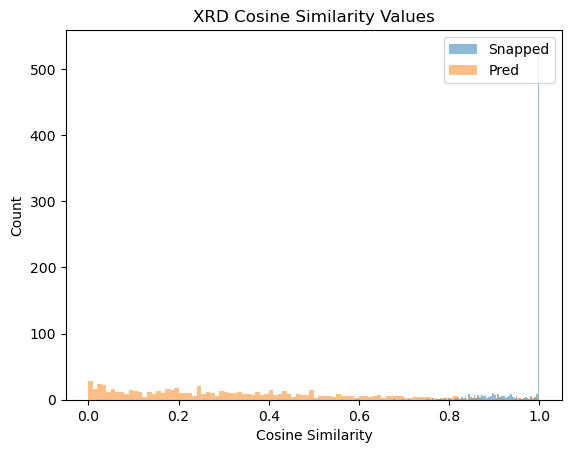

In [22]:
#overlay histograms for the snapped and pred cosine similarity values
plt.hist(snapped_cosine_similarities, bins=100, alpha=0.5, label='Snapped')
plt.hist(pred_cosine_similarities, bins=100, alpha=0.5, label='Pred')
plt.title('XRD Cosine Similarity Values')
plt.xlabel('Cosine Similarity')
plt.ylabel('Count')
plt.legend(loc='upper right')
plt.show()

#add the cosine similarity values to the dataframe
df['snapped_cosine_similarity'] = snapped_cosine_similarities
df['pred_cosine_similarity'] = pred_cosine_similarities

In [29]:
def loop_over_tol_list(directory, snapped_dirs, tol_list, label = "lattice"):
    snapped_total_rmsd_results = []
    pred_total_rmsd_results = []

    if len(tol_list) > 1:
        for tol in tol_list:
            if label == "lattice":
                (snapped_total_rmsd, pred_total_rmsd, snapped_pred_spacegroups, snapped_gt_spacegroups, pred_pred_spacegroups, pred_gt_spacegroups,
                    snapped_crystal_list, pred_crystal_list, gt_crystal_list) = snapped_structures_analysis(directory, snapped_dirs, ltol = tol)
            else: 
                (snapped_total_rmsd, pred_total_rmsd, snapped_pred_spacegroups, snapped_gt_spacegroups, pred_pred_spacegroups, pred_gt_spacegroups,
                    snapped_crystal_list, pred_crystal_list, gt_crystal_list) = snapped_structures_analysis(directory, snapped_dirs, angle_tol = tol)
            snapped_total_rmsd_results.append(snapped_total_rmsd)
            pred_total_rmsd_results.append(pred_total_rmsd)

    return snapped_total_rmsd_results, pred_total_rmsd_results

def get_rmsd_results(directory, snapped_dirs, lattice_tol_list, angle_tol_list):
    lp_snapped_total_rmsd_results, lp_pred_total_rmsd_results = loop_over_tol_list(directory, snapped_dirs, lattice_tol_list, label = "lattice")
    angle_snapped_total_rmsd_results, angle_pred_total_rmsd_results = loop_over_tol_list(directory, snapped_dirs, angle_tol_list, label = "angle")

    return lp_snapped_total_rmsd_results, lp_pred_total_rmsd_results, angle_snapped_total_rmsd_results, angle_pred_total_rmsd_results

def per_tolerance_match_rate_calc_and_plot(snapped_total_rmsd_results, pred_total_rmsd_results, tol_list, label = "lattice"):
    snapped_match_rates = []
    pred_match_rates = []
    for index in range(len(snapped_total_rmsd_results)): 
        snapped_total_rmsd = snapped_total_rmsd_results[index]
        pred_total_rmsd = pred_total_rmsd_results[index]

        snapped_total_rmsdnonans = np.array(snapped_total_rmsd)
        pred_total_rmsdnonans = np.array(pred_total_rmsd)

        snapped_match_rates.append(sum(snapped_total_rmsdnonans != None) / len(snapped_total_rmsdnonans))
        pred_match_rates.append(sum(pred_total_rmsdnonans != None) / len(pred_total_rmsdnonans))

    plt.plot(tol_list, snapped_match_rates, label = "Snapped")
    plt.plot(tol_list, pred_match_rates, label = "Pred")
    plt.title(f'Match Rates for Different {label} Tolerances')
    plt.xlabel(f'{label} Tolerance')
    plt.ylabel('Match Rate')
    plt.legend(loc='upper right')
    plt.show()

    return snapped_match_rates, pred_match_rates

def tolerance_analysis(directory, snapped_dirs, lattice_tol_list, angle_tol_list):
    lp_snapped_total_rmsd_results, lp_pred_total_rmsd_results, angle_snapped_total_rmsd_results, angle_pred_total_rmsd_results = get_rmsd_results(directory, snapped_dirs, lattice_tol_list, angle_tol_list)

    lp_snapped_match_rates, lp_pred_match_rates = per_tolerance_match_rate_calc_and_plot(lp_snapped_total_rmsd_results, lp_pred_total_rmsd_results, lattice_tol_list, label = "lattice")
    angle_snapped_match_rates, angle_pred_match_rates = per_tolerance_match_rate_calc_and_plot(angle_snapped_total_rmsd_results, angle_pred_total_rmsd_results, angle_tol_list, label = "angle")

    return lp_snapped_match_rates, lp_pred_match_rates, angle_snapped_match_rates, angle_pred_match_rates

In [34]:
directory = "/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/data_for_snapping/random_sample_test"
snapped_dirs = ["/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_1_results",
                "/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_2_results",
                "/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_3_results",
                "/home/gridsan/tmackey/Freedman_CDVAE_shared/XRD_CDVAE_Repo/scripts/02-09-2024_largescale_redo/test_4_results"]

lattice_tol_list = [0.01, 0.05, 0.1, 0.2, 0.3]
angle_tol_list = [0.5, 1, 5, 10]

In [35]:
lp_snapped_match_rates, lp_pred_match_rates, angle_snapped_match_rates, angle_pred_match_rates = tolerance_analysis(directory, snapped_dirs, lattice_tol_list, angle_tol_list)

  7%|▋         | 54/741 [00:02<00:30, 22.58it/s]/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/pymatgen/io/cif.py:1168: UserWarning: Issues encountered while parsing CIF: Some fractional coordinates rounded to ideal values to avoid issues with finite precision.
  warnings.warn("Issues encountered while parsing CIF: " + "\n".join(self.warnings))
 76%|███████▌  | 564/741 [00:00<00:00, 2813.45it/s]

snapped_ErClO_46.cif
snapped_Mg2ZnO3_376.cif
snapped_AlAu4_213.cif
snapped_Dy3Os_212.cif
snapped_BaCuO2_91.cif
snapped_Er2MgOs_22.cif
snapped_AgPbBrO_322.cif
snapped_Er2S3_49.cif
snapped_Ti5CuSb2_671.cif
snapped_Li2MnCoO4_623.cif
snapped_ScNiSn_486.cif
snapped_Li2CoSnO4_104.cif
snapped_AcLa3_246.cif
snapped_Lu2InPd2_664.cif
snapped_SrLiGaF6_131.cif
snapped_EuAu3_456.cif
snapped_Cs2HgI4_11.cif
snapped_TiRh_187.cif
snapped_CaAlSiH_265.cif
snapped_CdHgSe2_193.cif
snapped_W2NCl8_615.cif
snapped_ScAgSe2_121.cif
snapped_ZrNi2_461.cif
snapped_PmCl3_339.cif
snapped_Y(FeGe)2_103.cif
snapped_Ag2BiSbTe4_102.cif
snapped_Sc3TlC_344.cif
snapped_LiCa2Rh_471.cif
snapped_CeAlO3_349.cif
snapped_Cs2KYCl6_306.cif
snapped_Pr3Ni3Bi4_393.cif
snapped_Eu(ZnAs)2_229.cif
snapped_MgSn3_419.cif
snapped_SrCaTbBiO6_702.cif
snapped_Sr2Ti2O5_353.cif
snapped_CsSbWO6_175.cif
snapped_Ho2AgHg_308.cif
snapped_PuBr3_141.cif
snapped_ScInIr2_462.cif
snapped_Yb3Mg_151.cif
snapped_MgGaAg2_655.cif
snapped_Sr3(PO4)2_44.cif
snappe

100%|██████████| 741/741 [00:00<00:00, 2966.90it/s]


snapped_Zr5GaPb3_588.cif
snapped_WSe2_42.cif
snapped_DyCoSn2_421.cif
snapped_CeCrGe3_255.cif
snapped_Cu3(MoO3)4_701.cif
snapped_K2NaCeI6_715.cif
snapped_Cu_729.cif
snapped_Hf6Al2Ni_82.cif
snapped_AlCrCo2_279.cif
snapped_U2(PdRh)3_179.cif
snapped_LaCuPd_483.cif
snapped_AlFeO3_426.cif
snapped_TePHO5_579.cif
snapped_Lu3Ge3Ir2_194.cif
snapped_Rb2HgAu_41.cif
snapped_NdAgAu2_80.cif
snapped_CeSmZn2_89.cif
snapped_AcY3_670.cif
snapped_Ba2SrI6_252.cif
snapped_ZrVP_714.cif
snapped_BaPr2FeS5_334.cif
snapped_AcCdAu2_570.cif
snapped_LaGa2Co3_19.cif
snapped_Li4Fe3CoO8_388.cif
snapped_In2HgTe4_59.cif
snapped_Hf3TaFe8_425.cif
snapped_SiRh2_427.cif
snapped_Ca3(AlSi)2_610.cif
snapped_RbSmS2_47.cif
snapped_LaCr2Si2C_738.cif
snapped_Zr2Ni2Sn_572.cif
snapped_CsErO2_414.cif
snapped_ThAs_636.cif
snapped_Bi2TeSe2_191.cif
snapped_MgWO4_31.cif
snapped_MnZnPd2_507.cif
snapped_Dy(Al2Cu)4_1.cif
snapped_NdGaPd_668.cif
snapped_Tm2TlCd_20.cif
snapped_Er2Ge6Pt_477.cif
snapped_LaYbAl4_506.cif
snapped_Mg2AgHg_659.cif
sn

/tmp/ipykernel_3031245/326504882.py:168: RuntimeWarning: Mean of empty slice.
  mean_rms_dist = rms_dists[rms_dists != None].mean()
/home/gridsan/tmackey/.conda/envs/cdvae/lib/python3.8/site-packages/numpy/core/_methods.py:194: RuntimeWarning: invalid value encountered in scalar divide
  ret = ret / rcount


In [17]:
#make a new dataframe with the match rates with the different tolerances
#first generate a list with the diferent possible combinations of lattice and angle tolerances
tol_combinations = []
for angle_tol in [10]:
    for lattice_tol in [0.01, 0.05, 0.1, 0.2, 0.3]:
        tol_combinations.append((lattice_tol, angle_tol))

for lattice_tol in [0.3]:
    for angle_tol in [0.5, 1, 5, 10]:
        tol_combinations.append((lattice_tol, angle_tol))

#make a dataframe with the match rates for the different tolerances
match_rate_df = pd.DataFrame()

match_rate_df['lattice_tol'] = [i[0] for i in tol_combinations]
match_rate_df['angle_tol'] = [i[1] for i in tol_combinations]

In [29]:
#add 4 zeros to the end of lp snapped 
lp_snapped_match_rates = lp_snapped_match_rates + [0, 0, 0, 0]

#add 5 zeros to the beginning of angle snapped 
angle_snapped_match_rates = [0, 0, 0, 0] + angle_snapped_match_rates

ValueError: Length of values (13) does not match length of index (9)

In [30]:
match_rate_df['lp_snapped_match_rate'] = lp_snapped_match_rates[:9]
match_rate_df['lp_pred_match_rate'] = angle_snapped_match_rates[:9]

In [31]:
match_rate_df

,lattice_tol,angle_tol,lp_snapped_match_rate,lp_pred_match_rate
0,0.01,10.0,[0.7678812415654521],0
1,0.05,10.0,[0.8421052631578947],0
2,0.10,10.0,[0.8785425101214575],0
3,0.20,10.0,[0.9176788124156545],0
4,0.30,10.0,[0.9379217273954116],0
5,0.30,0.5,0,0
6,0.30,1.0,0,0
7,0.30,5.0,0,0
8,0.30,10.0,0,[0.7557354925775979]


In [32]:
#save the df and the match rates to a csv file
match_rate_df.to_csv("match_rate_df.csv")
df.to_csv("df.csv")

Get the MAPEs for the lengths and angles

In [ ]:
def mape_calculator(gt_crystals, best_crystals): 
    #calculate the MAPE for the lengths and angles
    per_crystal_mape_lengths = []   
    per_crystal_mape_angles = []
    for i in range(len(best_crystals)): 
        gt_lengths = gt_crystals[i]['lengths']
        gt_angles = gt_crystals[i]['angles']
        pred_lengths = best_crystals[i]['lengths']
        pred_angles = best_crystals[i]['angles']
        per_crystal_mape_lengths.append(MAPE(gt_lengths, pred_lengths))
        per_crystal_mape_angles.append(MAPE(gt_angles, pred_angles))

    return per_crystal_mape_lengths, per_crystal_mape_angles


In [62]:
def mape_plotter(gt_crystal_list, snapped_crystal_list, label = 'snapped'):
    per_crystal_mape_lengths, per_crystal_mape_angles = mape_calculator(gt_crystal_list[0], snapped_crystal_list[0])

    #plot histograms of the MAPE values for the lengths and angles
    plt.hist(per_crystal_mape_lengths, bins=100, alpha=0.5, label='Lengths')
    plt.title(f'MAPE Values for {label} Crystal Lengths')
    plt.xlabel('MAPE')
    plt.ylabel('Count')
    plt.show()

    print(f"the mean length mape is {np.mean(per_crystal_mape_lengths)}")
    print(f"the percentage with mape greater than 30 is {sum(np.array(per_crystal_mape_lengths) > 30) / len(per_crystal_mape_lengths)}")

    plt.hist(per_crystal_mape_angles, bins=100, alpha=0.5, label='Angles')
    plt.title(f'MAPE Values for {label} Crystal Angles')
    plt.xlabel('MAPE')
    plt.ylabel('Count')
    plt.show()

    print(f"the mean angle mape is {np.mean(per_crystal_mape_angles)}")
    print(f"the percentage with mape greater than 10 is {sum(np.array(per_crystal_mape_angles) > 10) / len(per_crystal_mape_angles)}")

In [63]:
mape_plotter(gt_crystal_list, snapped_crystal_list)
mape_plotter(gt_crystal_list, pred_crystal_list, label = 'pred')

NameError: name 'gt_crystal_list' is not defined

So snapping appears to be working largely as intended. However, while the cosine similarities match up nicely, it is clear that the RMSD values are not always improving despite clear improvements in the lattice parmeters. This might be addressed by doing DFT relaxations with the lattice parameters fixed. 

In [77]:
#first step is to write the cif files for the snapped structures
!mkdir /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/compounds_for_DFT_snapped
data_dir = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/compounds_for_DFT_snapped'
list_cif_writer(data_dir, snapped_crystal_list[0], [], symprec=0.01)

mkdir: cannot create directory '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/compounds_for_DFT_snapped': File exists


  1%|          | 3/507 [00:00<00:19, 26.35it/s]

100%|██████████| 507/507 [00:11<00:00, 44.77it/s]
0it [00:00, ?it/s]


Old code: 

In [ ]:
def cutoff_percentage(lower_cutoff, upper_cutoff, data): 
    data = np.array(data)
    #find what percent of the data is between the cutoffs
    data_in_range = data[(data > lower_cutoff) & (data < upper_cutoff)]
    percent_in_range = len(data_in_range)/len(data)
    print("Percent of data in range: ", percent_in_range)
#apply the cutoff_percentage function to the lengths and angles
cutoff_percentage(0, 10, per_crystal_mape_lengths)
cutoff_percentage(0, 5, per_crystal_mape_lengths)
#apply the cutoff_percentage function to the lengths and angles
cutoff_percentage(0, 10, per_crystal_mape_angles)
cutoff_percentage(0, 4, per_crystal_mape_angles)
#how much reduction in performance can we "afford" to loose? 
current_performance = 0.75 
percentage_reduction = 0.2 # let's say then 10% off of each 
print(current_performance * (1 - percentage_reduction)) 
#ok so I think for now, let's take stuff between 0 and 10 for both lengths and angles
#then, let's take the top 25% of the data for both the lengths and the angles
#let's do this by finding the indices so that we can use them to get the corresponding structures

lengths = np.array(per_crystal_mape_lengths)
angles = np.array(per_crystal_mape_angles)

# Step 1: Filter data to only include values between 0 and 10
filtered_lengths_indices = np.where((lengths > 0) & (lengths < 10))[0]
filtered_angles_indices = np.where((angles > 0) & (angles < 10))[0]

# Extract filtered data
filtered_lengths = lengths[filtered_lengths_indices]
filtered_angles = angles[filtered_angles_indices]

# Step 2: Find indices of the top 25% of the filtered data
top_25_percent_length_indices = filtered_lengths_indices[np.argsort(filtered_lengths)[-len(filtered_lengths)//4:]]
top_25_percent_angle_indices = filtered_angles_indices[np.argsort(filtered_angles)[-len(filtered_angles)//4:]]

#use the indicies to get the filtered lengths and angles
filtered_lengths = np.array(per_crystal_mape_lengths)[top_25_percent_length_indices]
filtered_angles = np.array(per_crystal_mape_angles)[top_25_percent_angle_indices]

#plot the distribution of the filtered lengths
plt.hist(filtered_lengths, bins=100)
plt.title('Filtered MAPE for Crystal Lengths')
plt.xlabel('MAPE')
plt.ylabel('Count')
plt.show()

#plot the distribution of the filtered angles
plt.hist(filtered_angles, bins=100)
plt.title('Filtered MAPE for Crystal Angles')
plt.xlabel('MAPE')
plt.ylabel('Count')
plt.show()
#use the indices to get the corresponding structures
worst_crystals_lengths_and_angles = []
for i in top_25_percent_length_indices: 
    worst_crystals_lengths_and_angles.append(best_crystals[i])
for i in top_25_percent_angle_indices:
    worst_crystals_lengths_and_angles.append(best_crystals[i])

#get the corresponding gt structures
worst_gt_structures = []
for i in top_25_percent_length_indices: 
    worst_gt_structures.append(gt_crystals[i])

for i in top_25_percent_angle_indices:
    worst_gt_structures.append(gt_crystals[i])
!mkdir /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/worst_crystals_lengths_and_angles
#save the structures as cif files
data_dir = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/worst_crystals_lengths_and_angles'
list_cif_writer(data_dir, worst_crystals_lengths_and_angles, worst_gt_structures)
# first, we need to get the lowest rmsd for each crystal in the set
lowest_rmsd = np.nanmin(fb_total_rmsd_stacked, axis=1)

lowest_rmsd_filtered = [i for j, i in enumerate(lowest_rmsd) if j not in rows_with_only_nans]
cutoff_percentage(0, 0.05, lowest_rmsd_filtered)
#ok, so it looks like we can exclude most of the outliers with a cutoff of 0.05
#then let's take the top 25% of the data for the rmsd values

# Step 1: Filter data to only include values between 0 and 0.05
lowest_rmsd_filtered = np.array(lowest_rmsd_filtered)
filtered_rmsd_indices = np.where((lowest_rmsd_filtered > 0) & (lowest_rmsd_filtered < 0.05))[0]

# Extract filtered data
filtered_rmsd = lowest_rmsd_filtered[filtered_rmsd_indices]

# Step 2: Find indices of the top 25% of the filtered data
top_25_percent_rmsd_indices = filtered_rmsd_indices[np.argsort(filtered_rmsd)[-len(filtered_rmsd)//4:]]
top_25_percent_rmsd_indices
#use the indices to get the filtered rmsd values
filtered_rmsd = np.array(lowest_rmsd_filtered)[top_25_percent_rmsd_indices]

#plot the distribution of the filtered rmsd
plt.hist(filtered_rmsd, bins=100)
plt.title('Filtered RMSD Values')
plt.xlabel('RMSD')
plt.ylabel('Count')
plt.show()

#use the indices to get the corresponding structures
worst_crystals_rmsd = []
for i in top_25_percent_rmsd_indices: 
    worst_crystals_rmsd.append(best_crystals[i])

#get the corresponding gt structures
worst_gt_structures_rmsd = []
for i in top_25_percent_rmsd_indices: 
    worst_gt_structures_rmsd.append(gt_crystals[i])
!mkdir /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/worst_crystals_rmsd
#save the structures as cif files
data_dir = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/worst_crystals_rmsd'
list_cif_writer(data_dir, worst_crystals_rmsd, worst_gt_structures_rmsd)

spacgroup_match = fb_pred_spacegroups == fb_gt_spacegroups
#sum across the rows to get the number of correct predictions
correct_predictions = np.sum(spacgroup_match, axis=1)
#now, filter using the rows with only nans
correct_predictions = np.array([i for j, i in enumerate(correct_predictions) if j not in rows_with_only_nans])
#now, find the indicies of compounds that have non-zero values
non_zero_indices = np.where(correct_predictions > 0)[0]

#use the indices to get the corresponding structures 
spacegroup_matches = []

for i in non_zero_indices:
    spacegroup_matches.append(best_crystals[i])

#use the indices to get the corresponding gt structures
spacegroup_matches_gt = []

for i in non_zero_indices:
    spacegroup_matches_gt.append(gt_crystals[i])

    #write these structures to cifs
!mkdir /home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/spacegroup_matches
data_dir = '/home/gridsan/tmackey/cdvae/scripts/1-22-2024_clean_impelementations/spacegroup_matches'
list_cif_writer(data_dir, spacegroup_matches, spacegroup_matches_gt)